# Seasonal Agriculture Performance Analysis

## Major Project - VOIS AICTE, 2026-2027

**Author:** Om Dayanand Nayak

**Program:** Data Analytics - Major

**Project Dataset:** seasonal_agriculture_performance_dataset.csv

# Table of Contents

1. Introduction to the Dataset
2. Problem Statement
3. Objectives
4. Importing Libraries
5. Loading the Dataset
6. Initial Data Exploration
7. Data Cleaning & Preparation
8. Descriptive Statistical Analysis
9. Outlier Investigation
10. Univariate Analysis
11. Bivariate Analysis
12. Multivariate Analysis
13. Correlation Analysis
14. Seasonal Performance Comparison
15. Student-Designed Analytical Questions
16. Key Insights
17. Evidence-Based Recommendations
18. Limitations of the Analysis
19. Conclusion

# 1. Introduction to the Dataset

The dataset represents agricultural activities carried out across different seasons, geographical regions, and farming conditions across eight Indian states.

It contains information about:

• Farming practices (Crop Type, Irrigation Method, Seed Quality)

• Environmental Conditions (Rainfall, Temperature, Humidity, Sunlight, Soil Health)

• Resource Usage (Fertilizer, Pesticide, Water Consumption)

• Production Outcomes (Yield, Production)

• Economic Performance (Cost, Revenue, Profit, Market Price)

The dataset covers three agricultural seasons:
- Kharif
- Rabi
- Zaid

The objective is to analyze seasonal agricultural performance and identify meaningful patterns.

# 2. Problem Statement

Agricultural performance changes due to seasonal variations in rainfall, temperature, soil conditions, irrigation methods and market prices.

This project aims to analyze seasonal agricultural performance using data analytics techniques to identify trends, patterns and factors affecting crop production and profitability.

# 3. Objectives

• Understand the agricultural dataset.

• Perform data cleaning.

• Explore seasonal agricultural performance.

• Analyze rainfall, crop yield and profit.

• Visualize important patterns using graphs.

• Generate meaningful insights and recommendations.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Importing Libraries

In [5]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [6]:
import os
print(os.listdir('/content'))

['.config', 'seasonal_agriculture_performance_dataset.csv', 'seasonal_agriculture_performance_dataset (1).csv', 'sample_data']


# 5. Loading the Dataset

In [7]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

# 6. Initial Data Exploration

In [8]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [9]:
df.shape

(4000, 28)

In [10]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

# 7. Data Cleaning & Preparation

In [12]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].mean())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].mean())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].mean())

In [16]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


# 8. Descriptive Statistical Analysis

In [17]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.185807,3.81818,11.960834,1.121186,0.641461,6.678828,31.216452,17.015074,27.742681,...,0.101747,13.307831,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,585.950000,26.90000,63.000000,7.300000,6.690000,26.500000,120.100000,57.500000,105.100000,...,0.830000,1.750000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.880000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


# 9. Outlier Investigation

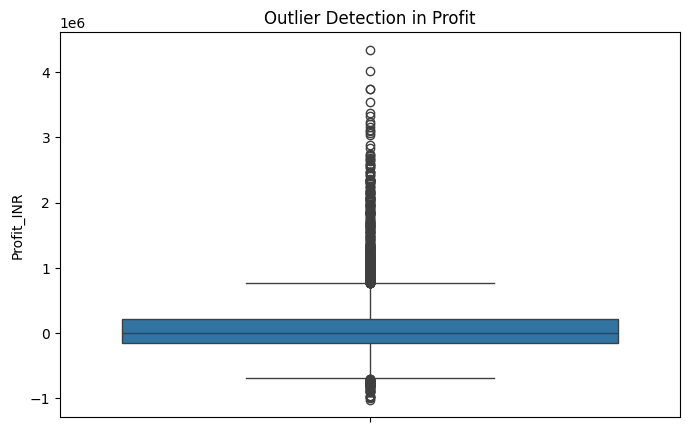

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Profit_INR"])

plt.title("Outlier Detection in Profit")

plt.show()

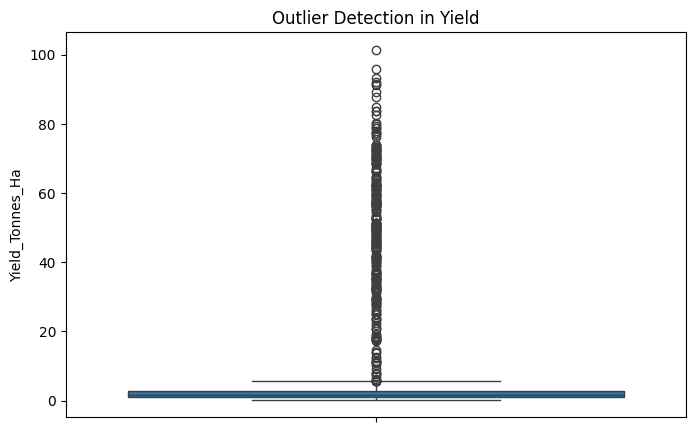

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Yield_Tonnes_Ha"])

plt.title("Outlier Detection in Yield")

plt.show()

# 10. Univariate Analysis

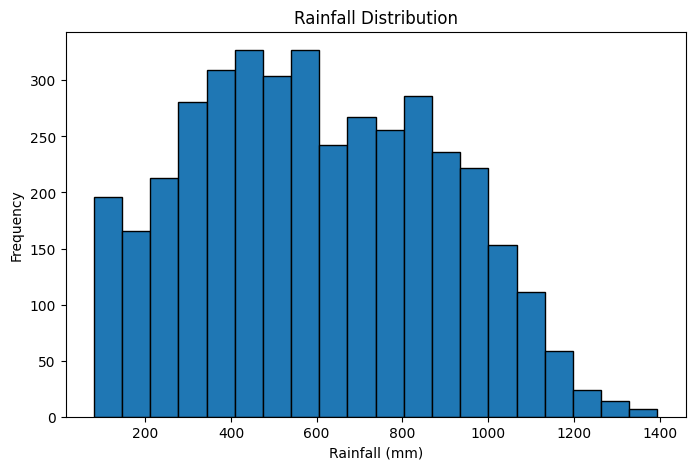

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df["Rainfall_mm"], bins=20, edgecolor="black")

plt.title("Rainfall Distribution")

plt.xlabel("Rainfall (mm)")

plt.ylabel("Frequency")

plt.show()

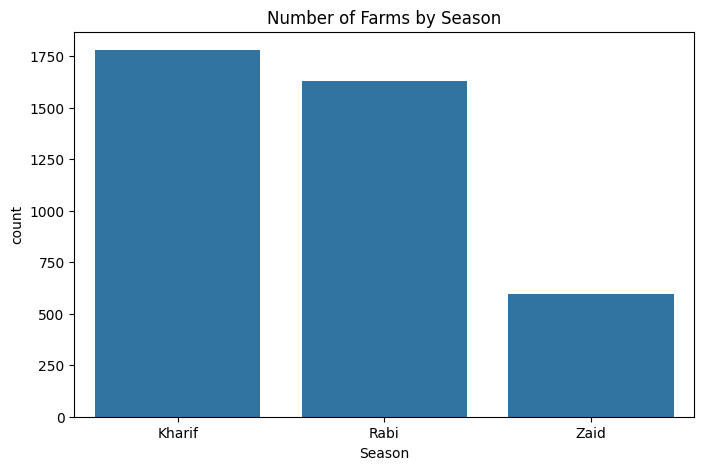

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x="Season", data=df)

plt.title("Number of Farms by Season")

plt.show()

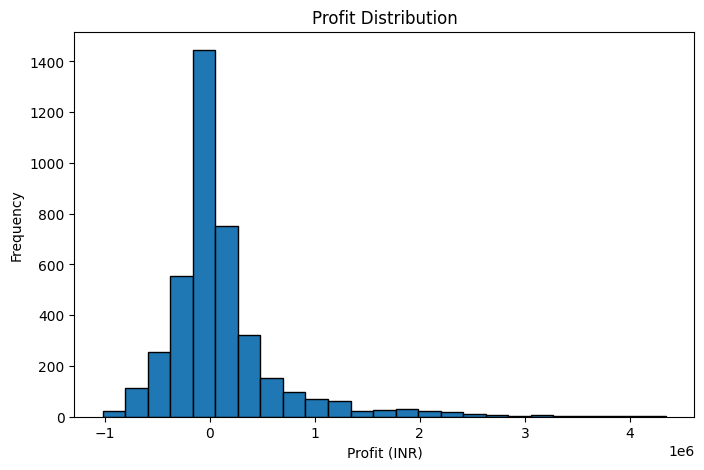

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit_INR"], bins=25, edgecolor="black")

plt.title("Profit Distribution")

plt.xlabel("Profit (INR)")

plt.ylabel("Frequency")

plt.show()

# 11. Bivariate Analysis

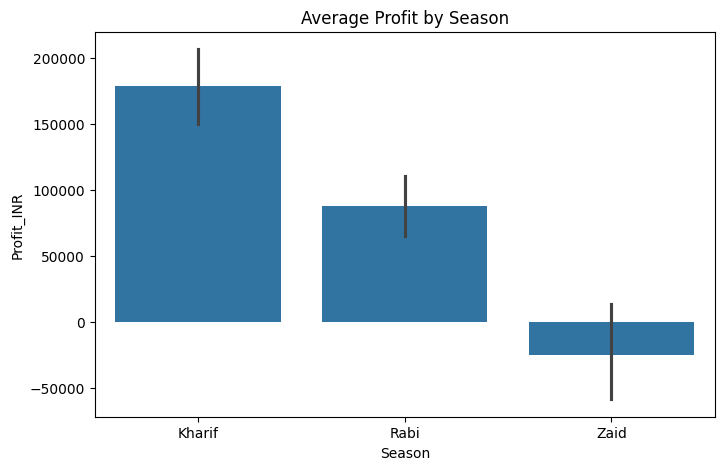

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(x="Season", y="Profit_INR", data=df)

plt.title("Average Profit by Season")

plt.show()

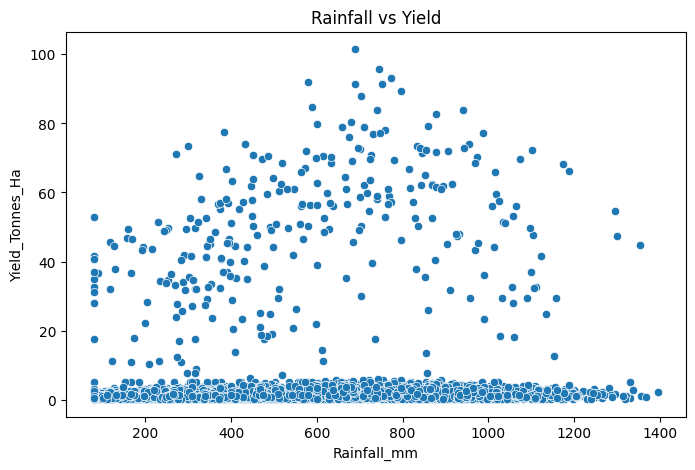

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Rainfall_mm", y="Yield_Tonnes_Ha", data=df)

plt.title("Rainfall vs Yield")

plt.show()

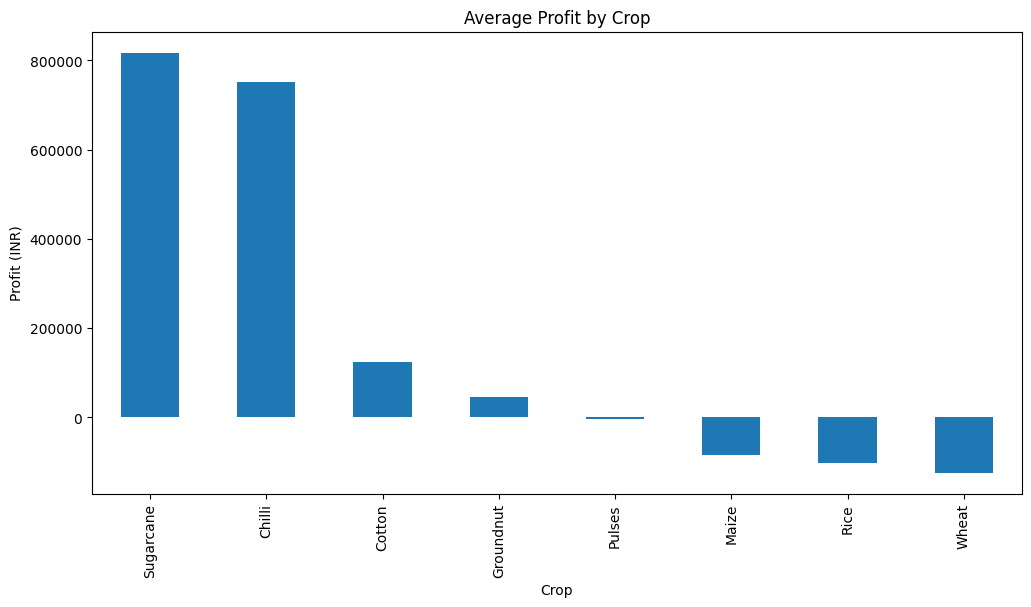

In [25]:
plt.figure(figsize=(12,6))

crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")

plt.ylabel("Profit (INR)")

plt.show()

# 12. Multivariate Analysis

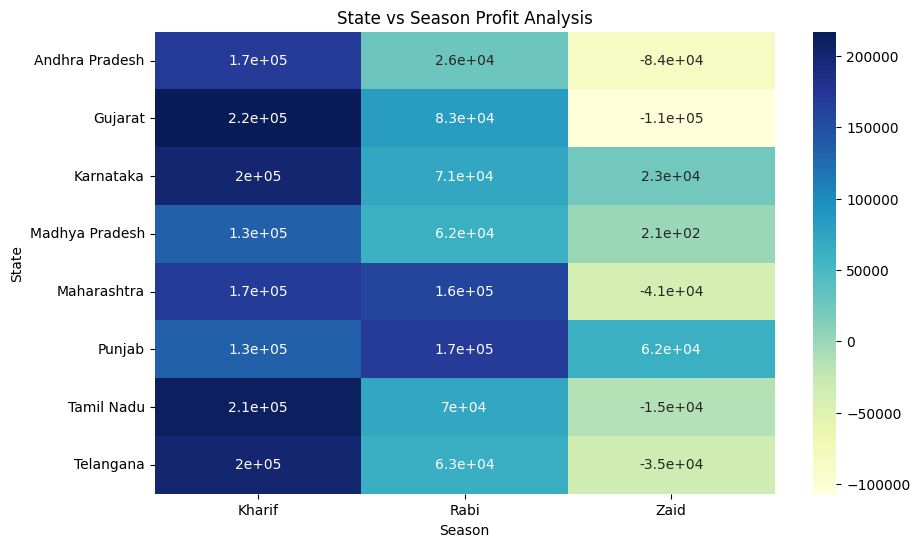

In [26]:
pivot = df.pivot_table(values="Profit_INR",
                       index="State",
                       columns="Season",
                       aggfunc="mean")

plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, cmap="YlGnBu")

plt.title("State vs Season Profit Analysis")

plt.show()

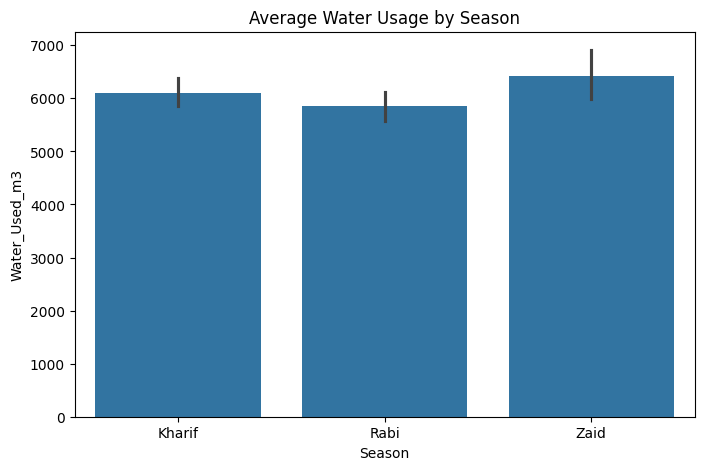

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(x="Season",
            y="Water_Used_m3",
            data=df)

plt.title("Average Water Usage by Season")

plt.show()

# 13. Correlation Analysis

In [28]:
corr = df.select_dtypes(include="number").corr()

corr

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007333,0.036870,0.000471,0.001821,0.009857,0.004061,0.013658,-0.006625,0.000195,...,0.015236,0.030064,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007333,1.000000,0.198631,0.521017,-0.362580,0.016650,0.508874,0.007582,0.021042,0.031389,...,-0.018687,0.030455,0.024441,0.000522,0.013091,0.098161,0.107639,0.002311,0.058112,0.621829
Avg_Temperature_C,0.036870,0.198631,1.000000,0.138136,-0.033863,0.029988,0.084044,0.018707,0.008508,0.022993,...,-0.031943,0.009302,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521017,0.138136,1.000000,-0.297298,0.028447,0.446461,0.001198,-0.005963,-0.003070,...,-0.045598,0.011236,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362580,-0.033863,-0.297298,1.000000,-0.017806,-0.302842,0.009920,0.001544,-0.014407,...,0.021257,-0.015330,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016650,0.029988,0.028447,-0.017806,1.000000,0.031166,0.006286,0.016620,-0.019407,...,-0.004181,-0.020561,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004061,0.508874,0.084044,0.446461,-0.302842,0.031166,1.000000,0.008873,0.013393,0.007838,...,-0.019545,0.010096,0.004814,0.016856,0.002776,0.079388,0.091272,0.003247,0.027783,0.375550
Nitrogen_kg_ha,0.013658,0.007582,0.018707,0.001198,0.009920,0.006286,0.008873,1.000000,0.010199,0.010490,...,0.014896,0.053566,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.021042,0.008508,-0.005963,0.001544,0.016620,0.013393,0.010199,1.000000,0.002847,...,-0.007575,0.047620,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031389,0.022993,-0.003070,-0.014407,-0.019407,0.007838,0.010490,0.002847,1.000000,...,0.006862,0.003819,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


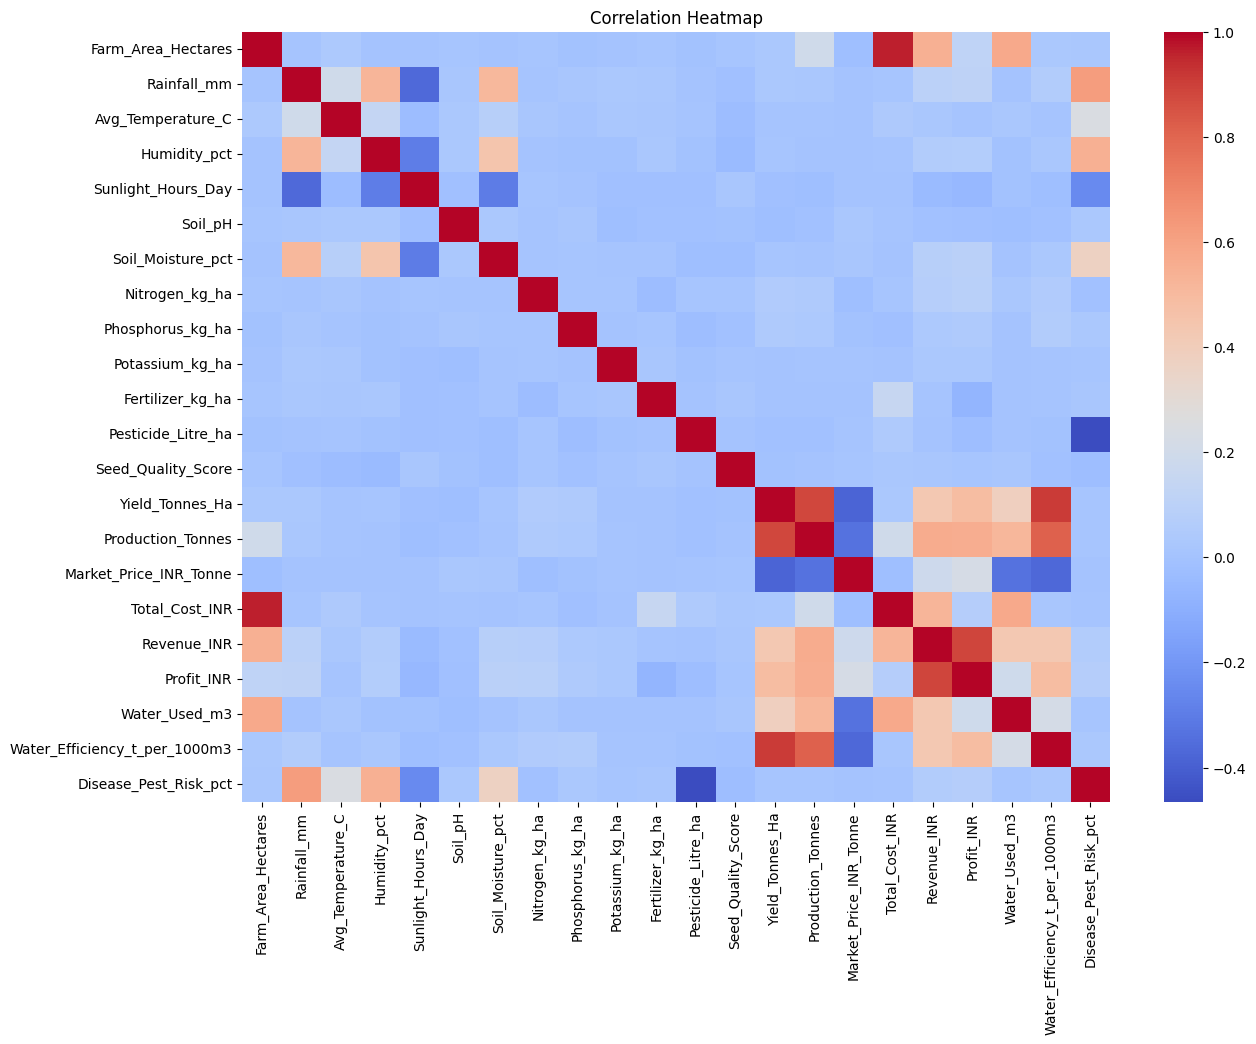

In [29]:
plt.figure(figsize=(14,10))

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

# 14. Seasonal Performance Comparison

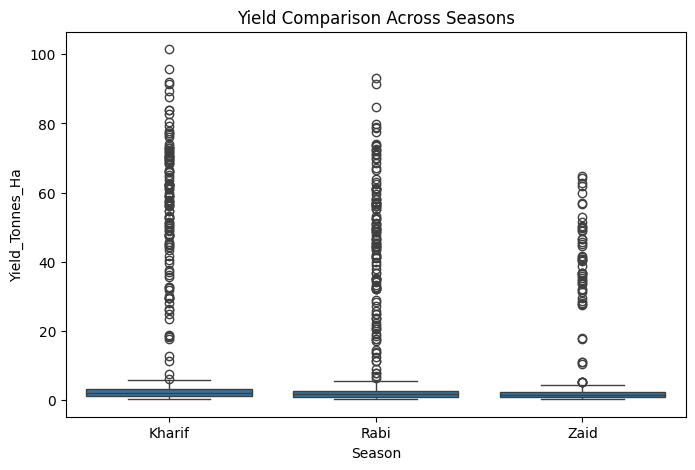

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Season",
            y="Yield_Tonnes_Ha",
            data=df)

plt.title("Yield Comparison Across Seasons")

plt.show()

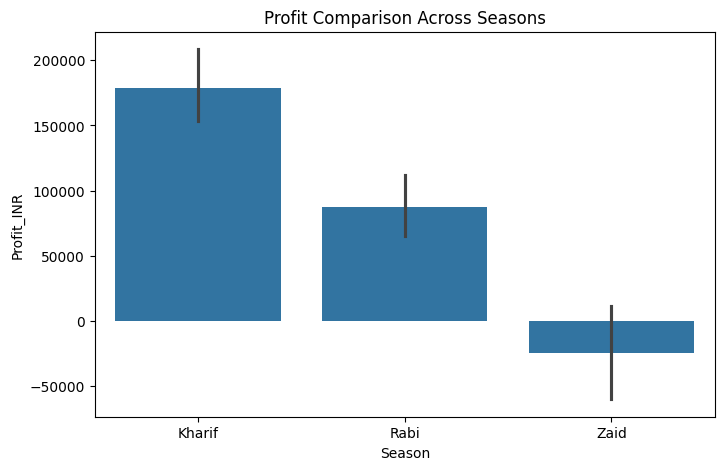

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(x="Season",
            y="Profit_INR",
            data=df)

plt.title("Profit Comparison Across Seasons")

plt.show()

# 15. Student-Designed Analytical Questions

Which season provides the highest average profit?

In [32]:
df.groupby("Season")["Profit_INR"].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


Which crop has the highest average production?

In [33]:
df.groupby("Crop")["Production_Tonnes"].mean().sort_values(ascending=False).head(10)

,Production_Tonnes
Crop,
Sugarcane,392.413016
Maize,21.781125
Rice,19.288623
Wheat,16.853909
Chilli,12.382888
Groundnut,9.655825
Cotton,9.395866
Pulses,7.401411


Which state has the highest average agricultural profit?

In [34]:
df.groupby("State")["Profit_INR"].mean().sort_values(ascending=False)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


# 16. Key Insights

## Key Insights

• The dataset contains agricultural information from three major seasons: Kharif, Rabi, and Zaid.

• Seasonal variations significantly affect crop yield and agricultural profit.

• Rainfall and soil moisture have an important influence on crop productivity.

• Different irrigation methods are adopted across farms depending on seasonal conditions.

• Revenue and profit show a strong positive relationship with production.

• Some crops generate higher average profits than others.

• Agricultural performance differs across states due to environmental and farming conditions.

# 17. Evidence-Based Recommendations

## Evidence-Based Recommendations

• Farmers should select crops based on seasonal suitability.

• Efficient irrigation techniques should be encouraged to improve water utilization.

• Proper fertilizer and soil nutrient management can improve crop yield.

• Rainfall forecasting should be used for better agricultural planning.

• Modern farming practices and quality seeds should be promoted.

• Government agencies should provide seasonal advisory services to farmers for improving profitability.

# 18. Limitations of the Analysis

## Limitations of the Analysis

• The analysis is limited to the variables available in the provided dataset.

• External factors such as government policies, market demand, pest outbreaks, and climate change were not included.

• Missing values were replaced using statistical techniques which may slightly influence the results.

• The findings are applicable only to the given dataset and may not represent all agricultural regions.

# 19. Conclusion

## Conclusion

This project successfully analyzed the Seasonal Agriculture Performance dataset using Python and Google Colab.

The dataset was cleaned, explored, and visualized using various statistical and graphical techniques. The analysis identified seasonal differences in agricultural performance, crop production, rainfall, water usage, and profitability.

The findings indicate that environmental conditions and farming practices play a significant role in agricultural productivity. Data analytics provides valuable insights that can help farmers, policymakers, and agricultural organizations make informed decisions to improve crop yield and profitability.

Overall, the project demonstrates how data analysis techniques can be effectively applied to understand seasonal agricultural performance and support evidence-based decision making.